In [6]:
!pip install pandas

In [7]:
!pip install numpy

In [8]:
!pip install matplotlib

# Kitsune Model Comparison

This notebook compares three versions of the model:

1. **Old baseline**
2. **Adaptive tuned**
3. **Adaptive tuned with z = 4.0**

We will load the CSV files, build a comparison table, and create plots to compare:

- pre-attack alerts
- detection latency
- throughput
- RAM usage
- runtime
- RMSE vs threshold around attack start

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

old_packet_df = pd.read_csv("old_model_packet_metrics.csv")
old_summary_df = pd.read_csv("old_model_summary_metrics.csv")

tuned_packet_df = pd.read_csv("adaptive_model_packet_metrics_tuned.csv")
tuned_summary_df = pd.read_csv("adaptive_model_summary_metrics_tuned.csv")

z4_packet_df = pd.read_csv("adaptive_model_packet_metrics_tuned_z4.csv")
z4_summary_df = pd.read_csv("adaptive_model_summary_metrics_tuned_z4.csv")

## Build a Summary Comparison Table

This cell combines the summary CSVs into one table so we can compare the three models side by side.

In [10]:
comparison = pd.DataFrame([
    {"model": "Old", **old_summary_df.iloc[0].to_dict()},
    {"model": "Adaptive Tuned", **tuned_summary_df.iloc[0].to_dict()},
    {"model": "Adaptive Tuned z=4.0", **z4_summary_df.iloc[0].to_dict()},
])

comparison

,model,total_packets,runtime_sec,packets_per_sec,FMgrace,ADgrace,execution_start_index,attack_start_index,phi,fixed_threshold,...,avg_ram_mb,adaptive_window_size,adaptive_z,adaptive_min_samples,adaptive_use_log,enable_drift,drift_window_size,drift_min_count,drift_cv_threshold,hard_ceiling_factor
0,Old,764137.0,4875.395153,156.733347,5000.0,50000.0,55001.0,70000.0,0.528243,0.528243,...,430.540133,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Adaptive Tuned,764137.0,5012.717664,152.439665,NaN,NaN,55001.0,70000.0,NaN,NaN,...,448.096861,2000.0,3.5,300.0,False,True,100.0,100.0,0.1,3.0
2,Adaptive Tuned z=4.0,764137.0,5997.416851,127.411020,NaN,NaN,55001.0,70000.0,NaN,NaN,...,450.512810,2000.0,4.0,300.0,False,True,100.0,100.0,0.1,3.0


## Main Evaluation Metrics

This table focuses on the most important metrics for comparison:

- pre-attack alerts
- post-attack alerts
- detection latency
- runtime
- throughput
- peak RAM

In [11]:
comparison[[
    "model",
    "pre_attack_alerts",
    "post_attack_alerts",
    "detection_latency_packets",
    "runtime_sec",
    "packets_per_sec",
    "peak_ram_mb",
    "avg_ram_mb"
]]

,model,pre_attack_alerts,post_attack_alerts,detection_latency_packets,runtime_sec,packets_per_sec,peak_ram_mb,avg_ram_mb
0,Old,20.0,566423.0,103.0,4875.395153,156.733347,566.457031,430.540133
1,Adaptive Tuned,949.0,575604.0,4.0,5012.717664,152.439665,612.421875,448.096861
2,Adaptive Tuned z=4.0,647.0,572507.0,7.0,5997.416851,127.411020,610.468750,450.512810


## Plot 1: Pre-Attack Alerts

This plot shows how many alerts were triggered before the known attack start.

A lower value is better here, because pre-attack alerts act like false positives in this evaluation.

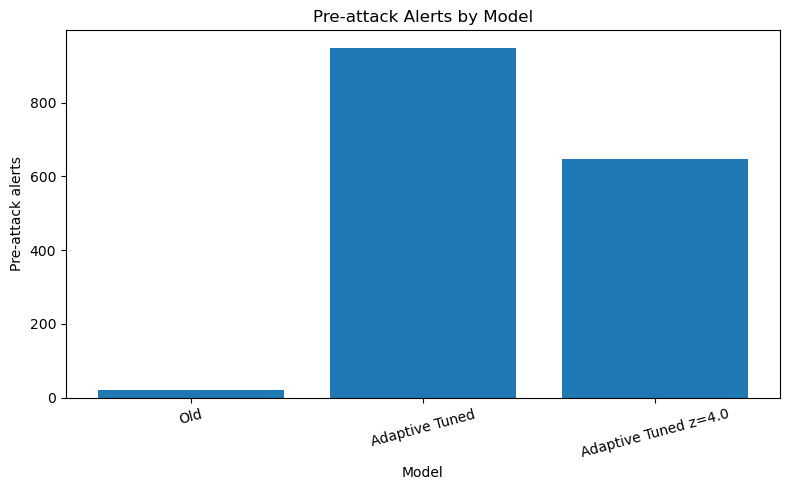

In [12]:
plt.figure(figsize=(8,5))
plt.bar(comparison["model"], comparison["pre_attack_alerts"])
plt.xlabel("Model")
plt.ylabel("Pre-attack alerts")
plt.title("Pre-attack Alerts by Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Plot 2: Detection Latency

This plot shows how quickly each model detects attack behavior after the known attack start.

A lower value is better here, because it means the model reacts faster.

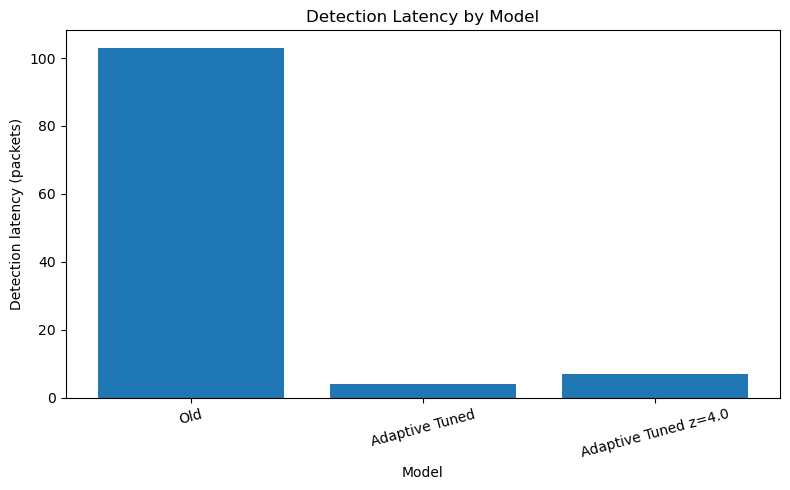

In [13]:
plt.figure(figsize=(8,5))
plt.bar(comparison["model"], comparison["detection_latency_packets"])
plt.xlabel("Model")
plt.ylabel("Detection latency (packets)")
plt.title("Detection Latency by Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Plot 3: Throughput

This plot compares how many packets per second each model processed.

A higher value is better, because it means the model is more efficient.

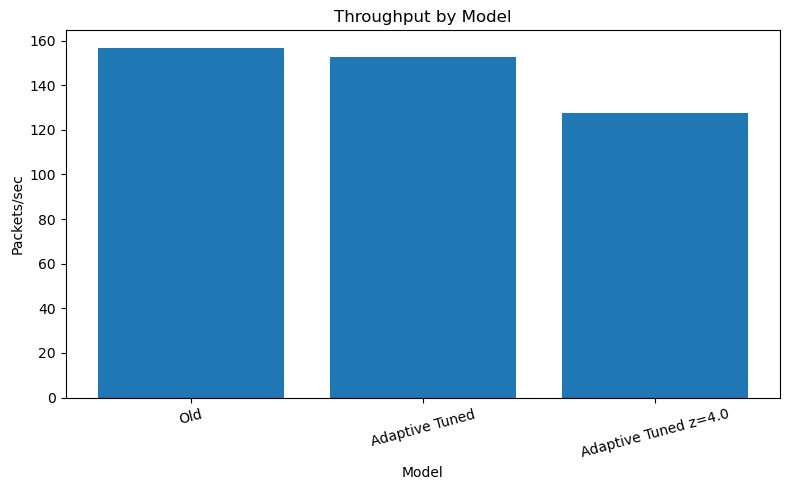

In [14]:
plt.figure(figsize=(8,5))
plt.bar(comparison["model"], comparison["packets_per_sec"])
plt.xlabel("Model")
plt.ylabel("Packets/sec")
plt.title("Throughput by Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Plot 4: Peak RAM Usage

This plot compares the maximum RAM used by each model during execution.

A lower value is better for lightweight deployment, especially in CPS and IoT contexts.

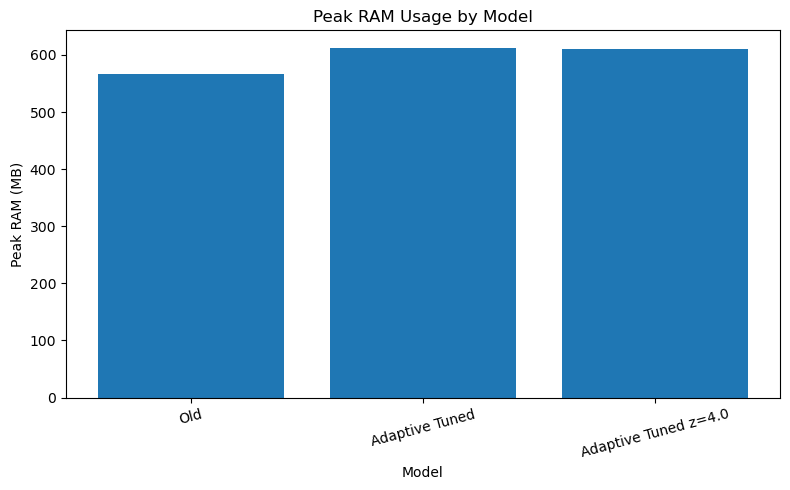

In [15]:
plt.figure(figsize=(8,5))
plt.bar(comparison["model"], comparison["peak_ram_mb"])
plt.xlabel("Model")
plt.ylabel("Peak RAM (MB)")
plt.title("Peak RAM Usage by Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Plot 5: Runtime

This plot compares the total runtime of the three models.

A lower value is better if we care about execution efficiency.

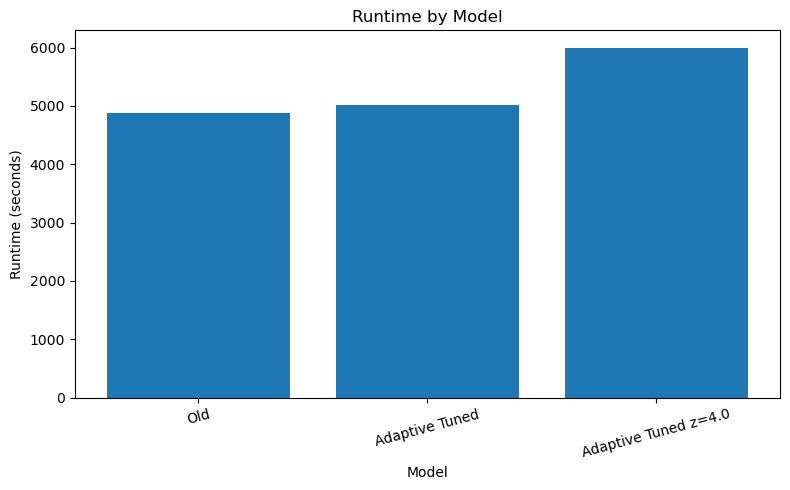

In [16]:
plt.figure(figsize=(8,5))
plt.bar(comparison["model"], comparison["runtime_sec"])
plt.xlabel("Model")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime by Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Helper Function for RMSE vs Threshold Plots

The next cells will show RMSE scores and threshold values around the attack start region.

We focus on a window around packet index 70,000 because that is where the attack begins in this evaluation.

In [17]:
attack_start = 70000
window_start = 65000
window_end = 73000

def rmse_threshold_plot(df, threshold_col, title):
    sub = df[(df["packet_index"] >= window_start) & (df["packet_index"] <= window_end)].copy()

    plt.figure(figsize=(12,5))
    plt.plot(sub["packet_index"], sub["rmse"], label="RMSE")
    plt.plot(sub["packet_index"], sub[threshold_col], label="Threshold")
    plt.axvline(attack_start, linestyle="--", label="Attack start")
    plt.yscale("log")
    plt.xlabel("Packet index")
    plt.ylabel("Value (log scale)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Plot 6: Old Model — RMSE vs Fixed Threshold

This plot shows how the original model behaves near the attack start.

The fixed threshold stays flat because it is based on the training phase and does not adapt over time.

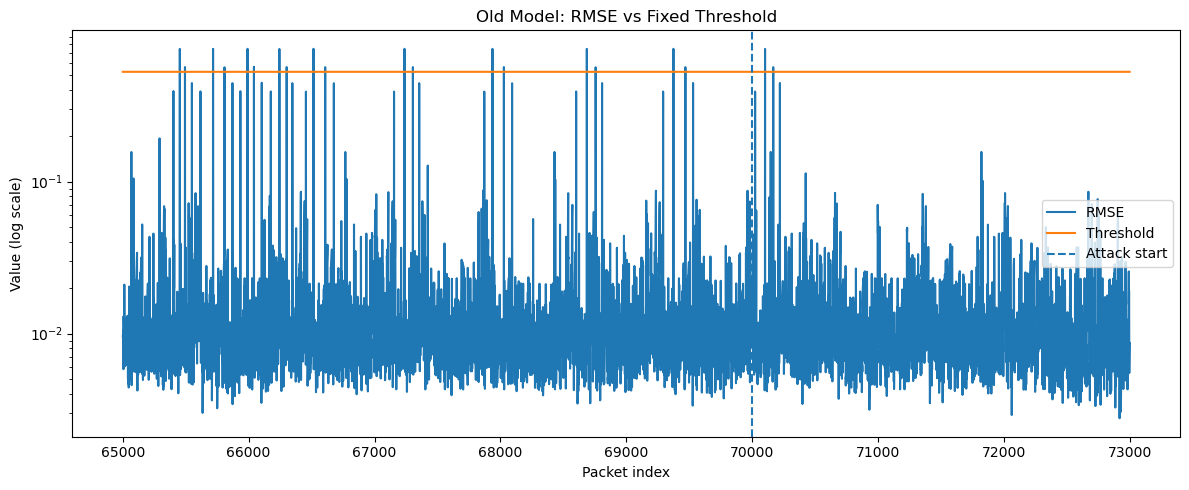

In [18]:
rmse_threshold_plot(
    old_packet_df,
    "fixed_threshold",
    "Old Model: RMSE vs Fixed Threshold"
)

## Plot 7: Adaptive Tuned — RMSE vs Adaptive Threshold

This plot shows the first tuned adaptive version.

The threshold moves because it is computed from a sliding window of recent RMSE scores.

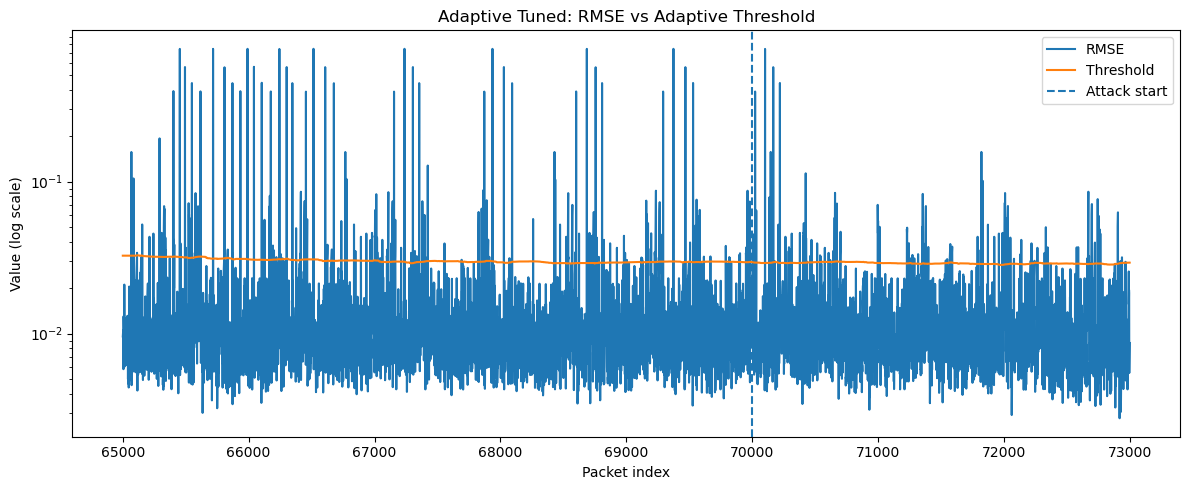

In [19]:
rmse_threshold_plot(
    tuned_packet_df,
    "adaptive_threshold",
    "Adaptive Tuned: RMSE vs Adaptive Threshold"
)

## Plot 8: Adaptive Tuned z = 4.0 — RMSE vs Adaptive Threshold

This plot shows the best adaptive configuration tested so far.

Increasing `z` made the threshold stricter, which reduced pre-attack alerts compared with the earlier adaptive settings.

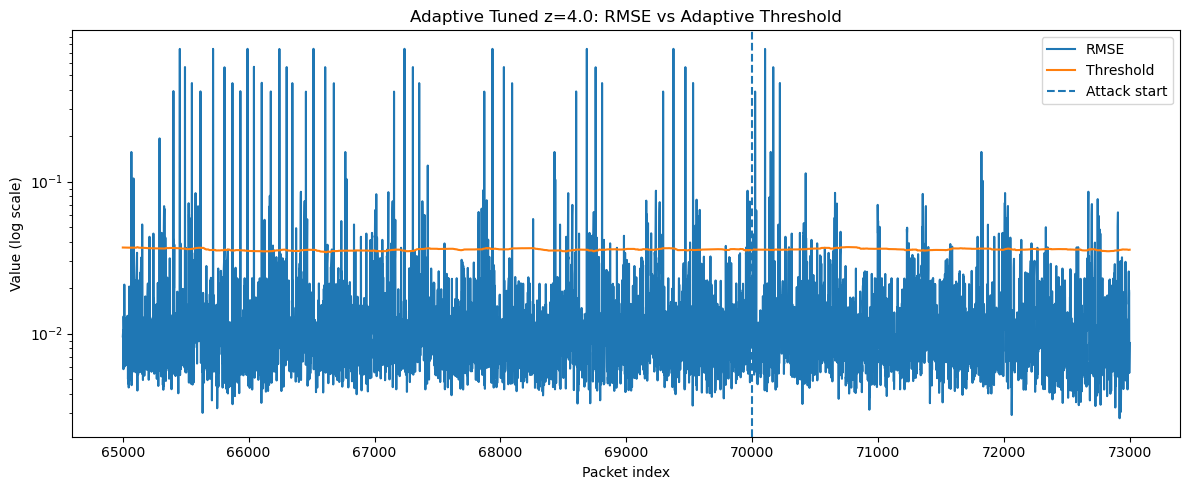

In [20]:
rmse_threshold_plot(
    z4_packet_df,
    "adaptive_threshold",
    "Adaptive Tuned z=4.0: RMSE vs Adaptive Threshold"
)

## Pre-Attack Alert Rate

Raw pre-attack alert counts are useful, but it is also helpful to normalize them by the number of benign evaluation packets.

This gives a pre-attack alert rate percentage.

In [21]:
benign_eval_packets = 70000 - (5000 + 50000 + 1)

comparison["pre_attack_alert_rate_pct"] = (
    comparison["pre_attack_alerts"] / benign_eval_packets * 100
)

comparison[[
    "model",
    "pre_attack_alerts",
    "pre_attack_alert_rate_pct",
    "detection_latency_packets",
    "packets_per_sec",
    "peak_ram_mb"
]]

,model,pre_attack_alerts,pre_attack_alert_rate_pct,detection_latency_packets,packets_per_sec,peak_ram_mb
0,Old,20.0,0.133342,103.0,156.733347,566.457031
1,Adaptive Tuned,949.0,6.327088,4.0,152.439665,612.421875
2,Adaptive Tuned z=4.0,647.0,4.313621,7.0,127.411020,610.468750


## Threshold vs RMSE 
Purpose:

    Show threshold follows data trend

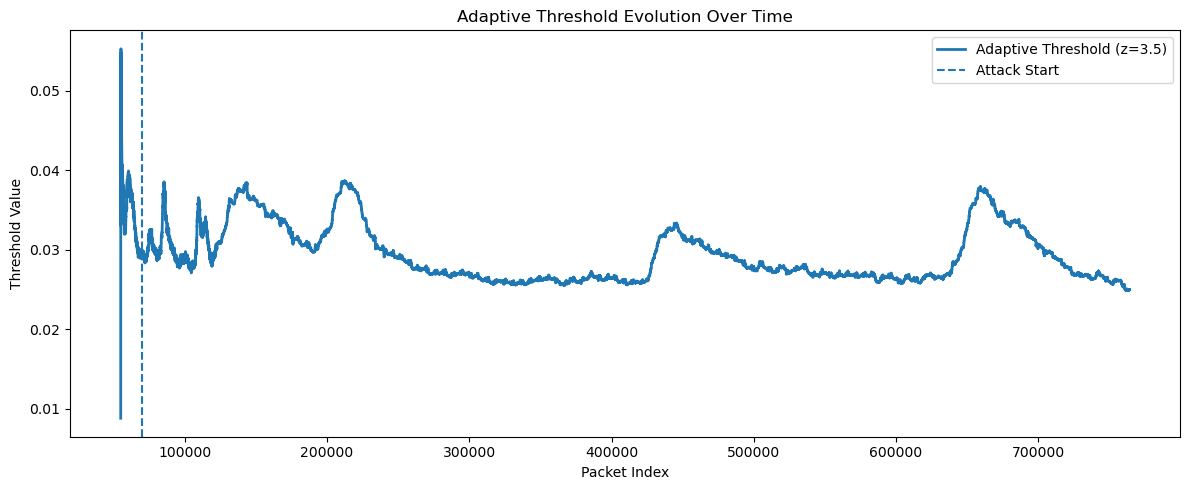

In [24]:
plt.figure(figsize=(12,5))

plt.plot(
    tuned_packet_df["packet_index"],
    tuned_packet_df["adaptive_threshold"],
    linewidth=2,
    label="Adaptive Threshold (z=3.5)"
)

plt.axvline(70000, linestyle="--", label="Attack Start")

plt.xlabel("Packet Index")
plt.ylabel("Threshold Value")
plt.title("Adaptive Threshold Evolution Over Time")

plt.legend()
plt.tight_layout()
plt.show()

## Threshold vs Packet Index

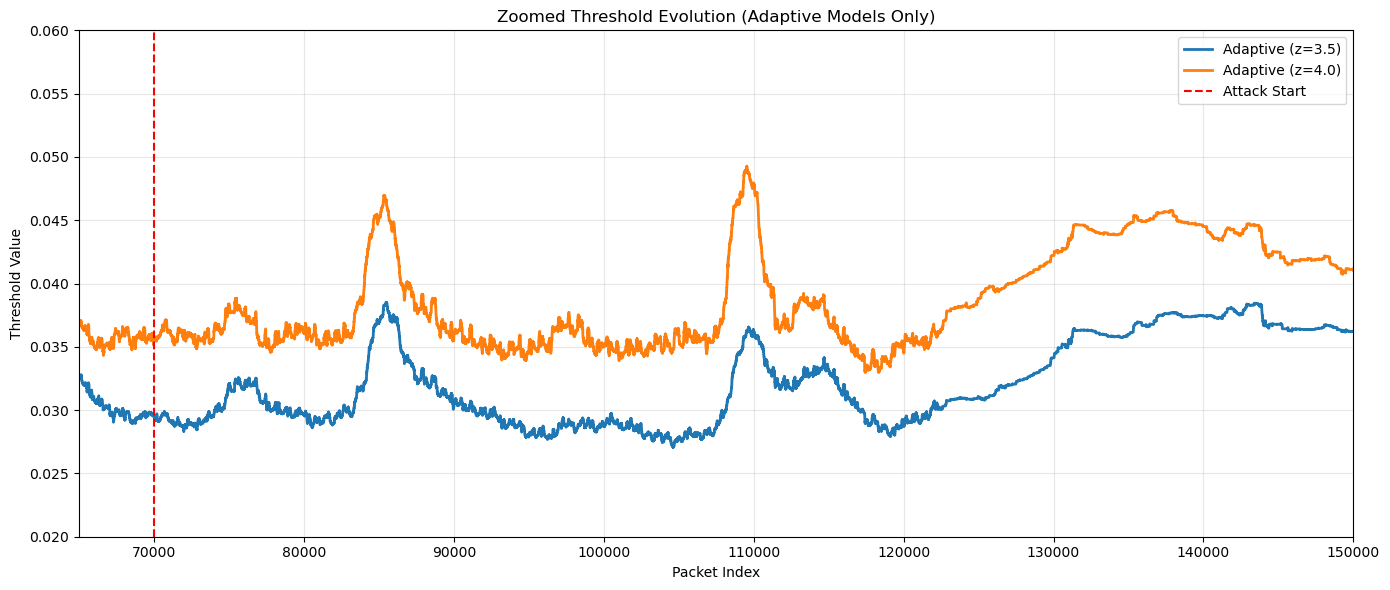

In [28]:
plt.figure(figsize=(14,6))

# Adaptive z=3.5
plt.plot(
    tuned_packet_df["packet_index"],
    tuned_packet_df["adaptive_threshold"],
    label="Adaptive (z=3.5)",
    linewidth=2
)

# Adaptive z=4.0
plt.plot(
    z4_packet_df["packet_index"],
    z4_packet_df["adaptive_threshold"],
    label="Adaptive (z=4.0)",
    linewidth=2
)

# Attack start
plt.axvline(70000, linestyle="--", color="red", label="Attack Start")

# 🔥 KEY FIXES
plt.ylim(0.02, 0.06)          # zoom Y
plt.xlim(65000, 150000)      # zoom X

plt.xlabel("Packet Index")
plt.ylabel("Threshold Value")
plt.title("Zoomed Threshold Evolution (Adaptive Models Only)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Thresholds VS RUN Time

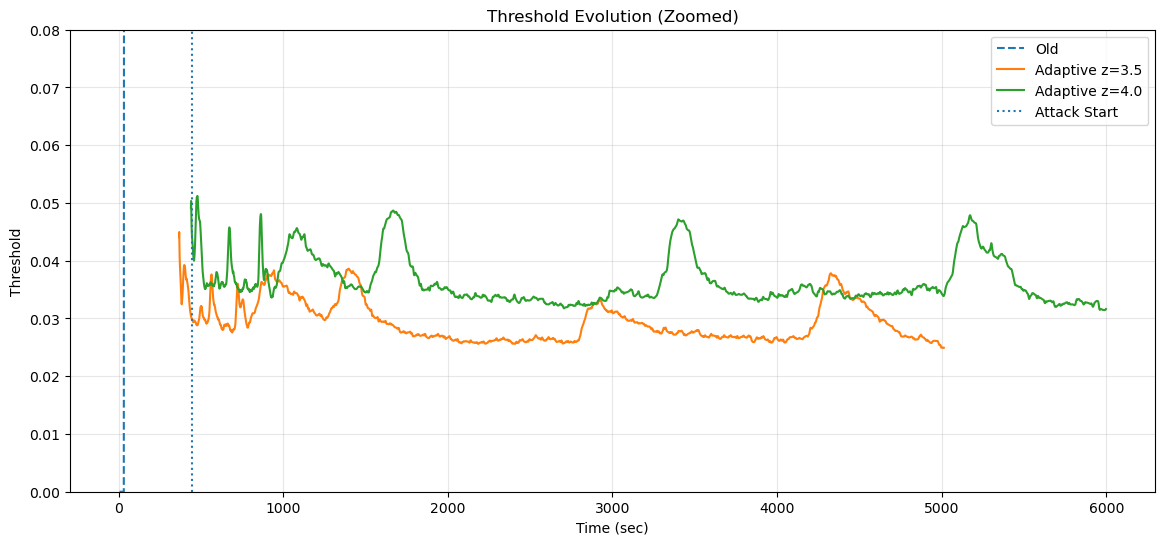

In [27]:
# Create time axis
old_packet_df["time_sec"] = old_packet_df["packet_index"] / 156.73
tuned_packet_df["time_sec"] = tuned_packet_df["packet_index"] / 152.44
z4_packet_df["time_sec"] = z4_packet_df["packet_index"] / 127.41

# Smooth thresholds
old_packet_df["thr_smooth"] = old_packet_df["fixed_threshold"].rolling(1000).mean()
tuned_packet_df["thr_smooth"] = tuned_packet_df["adaptive_threshold"].rolling(1000).mean()
z4_packet_df["thr_smooth"] = z4_packet_df["adaptive_threshold"].rolling(1000).mean()

plt.figure(figsize=(14,6))

plt.plot(old_packet_df["time_sec"], old_packet_df["thr_smooth"], '--', label="Old")
plt.plot(tuned_packet_df["time_sec"], tuned_packet_df["thr_smooth"], label="Adaptive z=3.5")
plt.plot(z4_packet_df["time_sec"], z4_packet_df["thr_smooth"], label="Adaptive z=4.0")

plt.ylim(0, 0.08)
plt.axvline(70000/156.73, linestyle=":", label="Attack Start")

plt.xlabel("Time (sec)")
plt.ylabel("Threshold")
plt.title("Threshold Evolution (Zoomed)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Final Interpretation

This final cell prints a short interpretation of the comparison results.

In [23]:
print("Interpretation:")
print("- The old model has the fewest pre-attack alerts, so it is strongest on false-positive control.")
print("- The adaptive variants improve detection latency substantially.")
print("- The tuned z=4.0 adaptive model is the strongest adaptive version among the tested adaptive settings.")
print("- The old model is still the better overall baseline, but the adaptive model is clearly better on responsiveness.")

Interpretation:
- The old model has the fewest pre-attack alerts, so it is strongest on false-positive control.
- The adaptive variants improve detection latency substantially.
- The tuned z=4.0 adaptive model is the strongest adaptive version among the tested adaptive settings.
- The old model is still the better overall baseline, but the adaptive model is clearly better on responsiveness.


## Key Takeaway

- **Old baseline** is strongest for false-alarm control and efficiency.
- **Adaptive tuned** improves attack responsiveness but remains too sensitive.
- **Adaptive tuned z = 4.0** is the best adaptive version tested so far because it reduces false alarms compared with earlier adaptive settings while still preserving a major improvement in detection latency.

## Conclusion

In this project, we enhanced Kitsune by replacing its fixed post-training threshold with a self-calibrating adaptive threshold based on a sliding window of recent RMSE scores. The new threshold was computed using the rolling mean and rolling standard deviation of recent anomaly scores, with additional drift-aware logic to support controlled adaptation.

Our experiments on the Mirai dataset showed that the adaptive model significantly improved responsiveness. In the final tuned configuration (`z = 4.0`), detection latency was reduced from **103 packets** in the original model to **7 packets**. This demonstrates that adaptive thresholding can improve attack response speed without changing the lightweight Kitsune scoring pipeline.

At the same time, the original fixed-threshold model remained stronger in false-alarm control and efficiency. The old baseline produced only **20 pre-attack alerts**, whereas the final adaptive model produced **647**. Therefore, the adaptive threshold is a promising enhancement for dynamic CPS and IoT environments, but careful tuning is still necessary to balance responsiveness and false positives.